Name: Umer Ali

Class: AI

Registration:22247

Batch: CS-sp23

Submitted To: Maam Tahira Kanwal

Project: Plant_Disease_Detection

Diseases: Detect disease in leaves of Apple, Corn, Bell Pepper, Potato, and Tomato plants.



Model already exists!


Model loaded successfully!


Saving PotatoHealthy1.JPG to PotatoHealthy1.JPG
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step

Prediction: Potato___healthy
Confidence: 98.19%
Treatment: nan
Recommended Medicine: nan
Suggestion: Use certified seeds


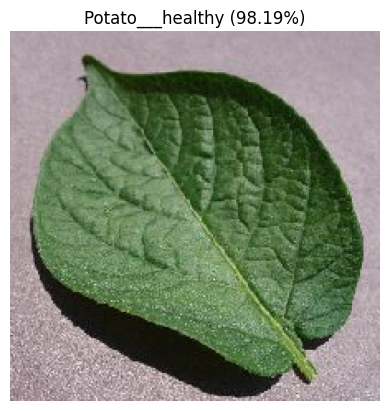

In [5]:
# =====================================================
# PLANT DISEASE DETECTION WITH TREATMENT SUGGESTION
# =====================================================

# -----------------------------
# Install required packages
# -----------------------------
!pip install -q gdown
import gdown
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# -----------------------------
# Parameters
# -----------------------------
IMG_SIZE = 224
MODEL_PATH = "plant_disease_model.h5"

# -----------------------------
# Download pre-trained model from Google Drive
# -----------------------------
file_id = "1qmiHFhAf5v8UM7G5GiQFP-nt1jGFugZ_"  # your file ID
if not os.path.exists(MODEL_PATH):
    gdown.download(f"https://drive.google.com/uc?id={file_id}", MODEL_PATH, quiet=False)
else:
    print("Model already exists!")

# -----------------------------
# Load the model
# -----------------------------
from tensorflow.keras.models import load_model
model = load_model(MODEL_PATH)
print("Model loaded successfully!")

# -----------------------------
# Define disease treatment CSV
# -----------------------------
csv_content = """disease,treatment,medicine,suggestion
Apple___Apple_scab,Remove infected leaves,Myclobutanil,Spray every 7-10 days
Apple___Black_rot,Prune infected branches,Captan,Spray weekly
Apple___Cedar_apple_rust,Remove cedar galls nearby,Mancozeb,Spray every 10 days
Apple___healthy,None,None,Maintain proper irrigation
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,Remove crop debris,Azoxystrobin,Spray every 14 days
Corn_(maize)___Common_rust_,Remove infected leaves,Propiconazole,Spray twice at 10-day interval
Corn_(maize)___Northern_Leaf_Blight,Destroy residue,Chlorothalonil,Spray every 7-14 days
Corn_(maize)___healthy,None,None,Ensure crop rotation
Pepper__bell___Bacterial_spot,Remove infected plants,Copper fungicide,Spray weekly
Pepper__bell___healthy,None,None,Avoid overwatering
Potato___Early_blight,Remove infected foliage,Chlorothalonil,Spray every 7-10 days
Potato___Late_blight,Destroy infected plants,Mancozeb,Spray twice weekly
Potato___healthy,None,None,Use certified seeds
Tomato_Bacterial_spot,Remove infected leaves,Copper fungicide,Spray weekly
Tomato_Early_blight,Prune affected leaves,Chlorothalonil,Spray every 10 days
Tomato_Late_blight,Remove infected plants,Mancozeb,Spray twice weekly
Tomato_Leaf_Mold,Improve airflow,Chlorothalonil,Spray weekly
Tomato_Septoria_leaf_spot,Remove infected leaves,Copper fungicide,Spray every 7-10 days
Tomato_Spider_mites_Two_spotted_spider_mite,Wash leaves,Abamectin,Spray every 5-7 days
Tomato__Target_Spot,Remove infected foliage,Azoxystrobin,Spray every 10 days
Tomato__Tomato_YellowLeaf__Curl_Virus,Remove infected plants,Imidacloprid,Control whiteflies weekly
Tomato__Tomato_mosaic_virus,Remove infected plants,None,Disinfect tools
Tomato_healthy,None,None,Maintain proper fertilization
"""

with open("disease_treatments.csv", "w") as f:
    f.write(csv_content)
treatment_df = pd.read_csv("disease_treatments.csv")

def get_treatment(disease):
    row = treatment_df[treatment_df["disease"] == disease]
    if not row.empty:
        return row.iloc[0]["treatment"], row.iloc[0]["medicine"], row.iloc[0]["suggestion"]
    return "Consult expert", "N/A", "No data available"

# -----------------------------
# Define classes (order must match model)
# -----------------------------
class_names = [
    'Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy',
    'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_',
    'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy',
    'Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy',
    'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy',
    'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold',
    'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite',
    'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus',
    'Tomato__Tomato_mosaic_virus', 'Tomato_healthy'
]

# -----------------------------
# Prediction function
# -----------------------------
def predict_image():
    from google.colab import files
    uploaded = files.upload()
    for fn in uploaded.keys():
        img = load_img(fn, target_size=(IMG_SIZE, IMG_SIZE))
        img_array = img_to_array(img)/255.0
        img_array = np.expand_dims(img_array, axis=0)

        prediction = model.predict(img_array)
        predicted_class = class_names[np.argmax(prediction)]
        confidence = np.max(prediction) * 100

        print("\nPrediction:", predicted_class)
        print("Confidence: {:.2f}%".format(confidence))

        treatment, medicine, suggestion = get_treatment(predicted_class)
        print("Treatment:", treatment)
        print("Recommended Medicine:", medicine)
        print("Suggestion:", suggestion)

        plt.imshow(img)
        plt.title(f"{predicted_class} ({confidence:.2f}%)")
        plt.axis("off")
        plt.show()

# -----------------------------
# Run prediction
# -----------------------------
predict_image()